In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
!unzip "/content/drive/MyDrive/archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: paddy-disease-classification/train_images/hispa/104947.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104955.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104959.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104960.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104967.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104969.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104973.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104976.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104979.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104981.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104985.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104986.jpg  
  inflating: paddy-disease-classification/train_images/hispa/

In [4]:
dataset_path = "/content/paddy-disease-classification"
train_path = os.path.join(dataset_path, "train_images")
test_path = os.path.join(dataset_path, "test_images")

📸 Sample image found: /content/paddy-disease-classification/train_images/bacterial_leaf_streak/flip_hoz_129.jpg


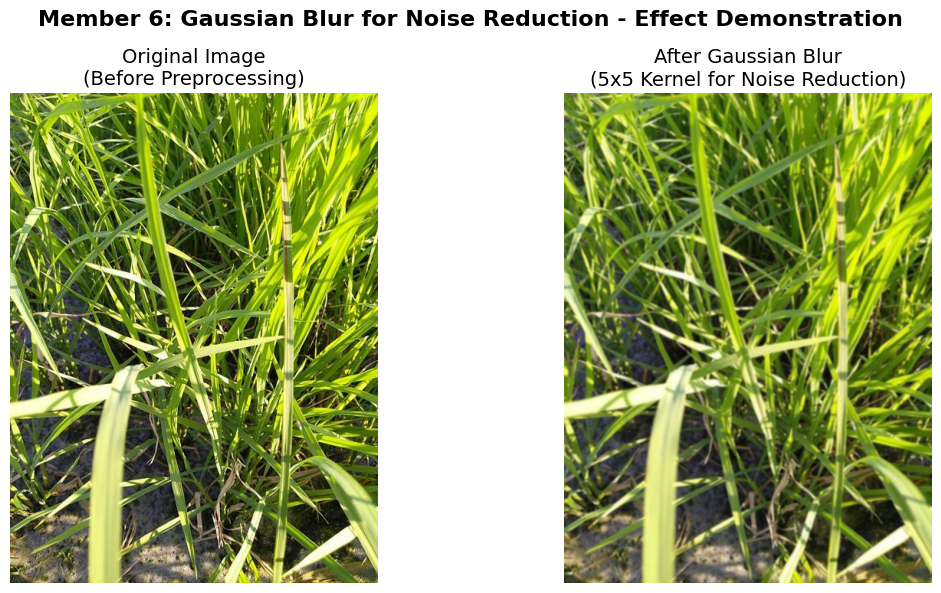

 Original image shape: (640, 480, 3)
 Blurred image shape: (640, 480, 3)
 Gaussian kernel used: 5x5
 Effect: Reduced high-frequency noise while preserving main features


In [6]:
sample_image_path = None
for root, _, files in os.walk(train_path):  # Fixed: removed asterisk
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_image_path = os.path.join(root, file)
            break
    if sample_image_path:
        break

if sample_image_path:
    print(f"📸 Sample image found: {sample_image_path}")

    # Load the image using OpenCV
    original_image = cv2.imread(sample_image_path)

    # Convert from BGR to RGB for proper matplotlib display
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Apply Gaussian blur with 5x5 kernel (same as in pipeline)
    blurred_image = cv2.GaussianBlur(original_image, (5, 5), 0)

    # Convert blurred image from BGR to RGB
    blurred_image_rgb = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB)

    # Create side-by-side comparison
    plt.figure(figsize=(12, 6))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image_rgb)
    plt.title('Original Image\n(Before Preprocessing)', fontsize=14)
    plt.axis('off')

    # Blurred image
    plt.subplot(1, 2, 2)
    plt.imshow(blurred_image_rgb)
    plt.title('After Gaussian Blur\n(5x5 Kernel for Noise Reduction)', fontsize=14)
    plt.axis('off')

    plt.suptitle('Member 6: Gaussian Blur for Noise Reduction - Effect Demonstration',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Show image details
    print(f" Original image shape: {original_image_rgb.shape}")
    print(f" Blurred image shape: {blurred_image_rgb.shape}")
    print(f" Gaussian kernel used: 5x5")
    print(f" Effect: Reduced high-frequency noise while preserving main features")

else:
    print(" No image files found in the training data directory.")
    print("Please check that 'train_path' variable is correctly defined.")

In [7]:
sample_images = []
sample_paths = []
classes_found = []

# Collect one sample from each class (up to 6 classes)
for class_folder in os.listdir(train_path)[:6]:  # Limit to 6 for display
    class_path = os.path.join(train_path, class_folder)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path)[:1]:  # Take first image from each class
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(class_path, file)
                sample_paths.append(image_path)
                classes_found.append(class_folder)
                break

if sample_paths:
    plt.figure(figsize=(18, 12))

    for i, (image_path, class_name) in enumerate(zip(sample_paths, classes_found)):
        # Load and process image
        original = cv2.imread(image_path)
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        blurred = cv2.GaussianBlur(original, (5, 5), 0)
        blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

        # Original image
        plt.subplot(2, len(sample_paths), i + 1)
        plt.imshow(original_rgb)
        plt.title(f'Original\n{class_name}', fontsize=10)
        plt.axis('off')

        # Blurred image
        plt.subplot(2, len(sample_paths), i + 1 + len(sample_paths))
        plt.imshow(blurred_rgb)
        plt.title(f'Blurred\n{class_name}', fontsize=10)
        plt.axis('off')

    plt.suptitle('Gaussian Blur Effect Across Different Disease Classes',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f" Demonstrated blur effect on {len(sample_paths)} different classes")
    print(f"Classes shown: {', '.join(classes_found)}")


Output hidden; open in https://colab.research.google.com to view.

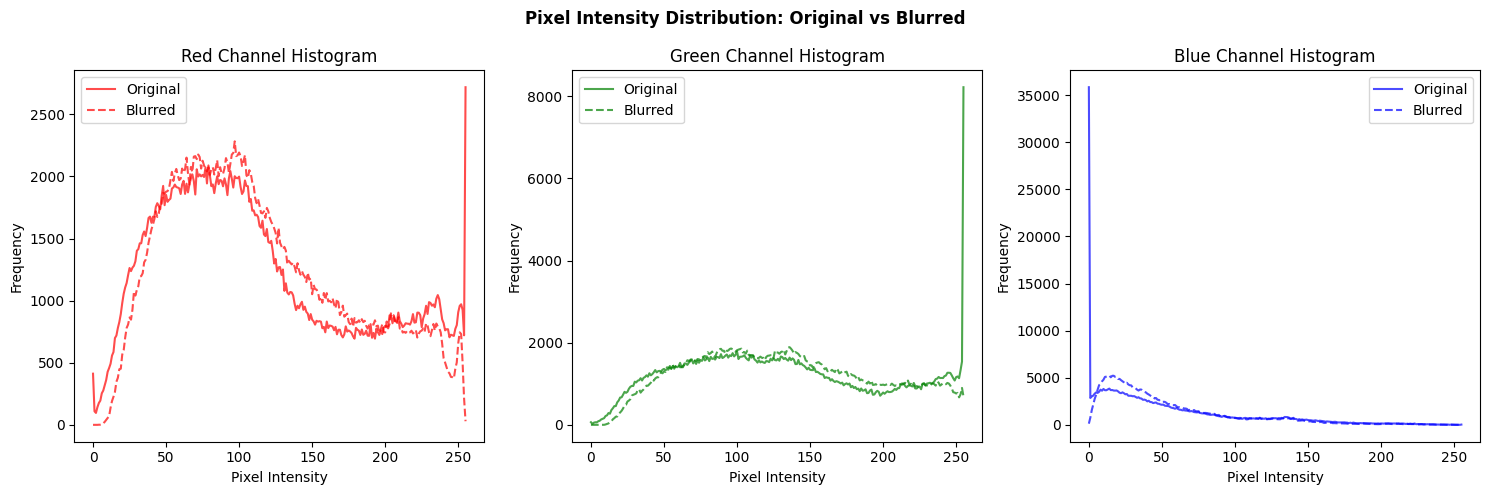

 Histogram Analysis:
• Blurred images show smoother intensity distributions
• Sharp peaks in original are smoothed out
• This indicates effective noise reduction

 MEMBER 6 PREPROCESSING CONTRIBUTION SUMMARY:
Technique: Gaussian Blur with 5x5 kernel
Purpose: Noise reduction and improved generalization
Application: Training data only (before model training)
Integration: Seamlessly fits into TensorFlow pipeline


In [8]:
if sample_image_path:
    # Load one more time for technical analysis
    img = cv2.imread(sample_image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Show pixel intensity histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = ['red', 'green', 'blue']

    for i, color in enumerate(colors):
        # Original histogram
        hist_orig = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])

        # Blurred histogram
        blurred_for_hist = cv2.GaussianBlur(img_rgb, (5, 5), 0)
        hist_blur = cv2.calcHist([blurred_for_hist], [i], None, [256], [0, 256])

        axes[i].plot(hist_orig, color=color, alpha=0.7, label='Original')
        axes[i].plot(hist_blur, color=color, alpha=0.7, linestyle='--', label='Blurred')
        axes[i].set_title(f'{color.capitalize()} Channel Histogram')
        axes[i].legend()
        axes[i].set_xlabel('Pixel Intensity')
        axes[i].set_ylabel('Frequency')

    plt.suptitle('Pixel Intensity Distribution: Original vs Blurred', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(" Histogram Analysis:")
    print("• Blurred images show smoother intensity distributions")
    print("• Sharp peaks in original are smoothed out")
    print("• This indicates effective noise reduction")

print("\n MEMBER 6 PREPROCESSING CONTRIBUTION SUMMARY:")
print("=" * 55)
print("Technique: Gaussian Blur with 5x5 kernel")
print("Purpose: Noise reduction and improved generalization")
print("Application: Training data only (before model training)")
print("Integration: Seamlessly fits into TensorFlow pipeline")
print("=" * 55)